In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
 
warnings.filterwarnings('ignore')

In [3]:
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#333333',
    'axes.labelcolor':  '#cccccc',
    'xtick.color':      '#888888',
    'ytick.color':      '#888888',
    'text.color':       '#eeeeee',
    'grid.color':       '#2a2a2a',
    'grid.linestyle':   '--',
    'axes.grid':        True,
    'font.family':      'monospace',
    'figure.dpi':       130,
})
NETFLIX_RED = '#E50914'
ACCENT      = '#F5A623'
COOL        = '#00B4D8'
MUTED       = '#888888'

In [4]:
df = pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')
 
print("=" * 60)
print("SECTION 1 — DATA STRUCTURE & TYPES")
print("=" * 60)
print(f"\n Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f" Duplicate rows: {df.duplicated().sum()}")
print("\n── Column Data Types ──")
print(df.dtypes)
print("\n── First 5 Rows ──")
print(df.head())
print("\n── Statistical Summary ──")
print(df.describe(include='all'))

SECTION 1 — DATA STRUCTURE & TYPES

 Shape         : 8,807 rows × 12 columns
 Duplicate rows: 0

── Column Data Types ──
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

── First 5 Rows ──
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...  


SECTION 2 — DATA QUALITY AUDIT
            Missing Count  Missing %
director             2634      29.91
cast                  825       9.37
country               831       9.44
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


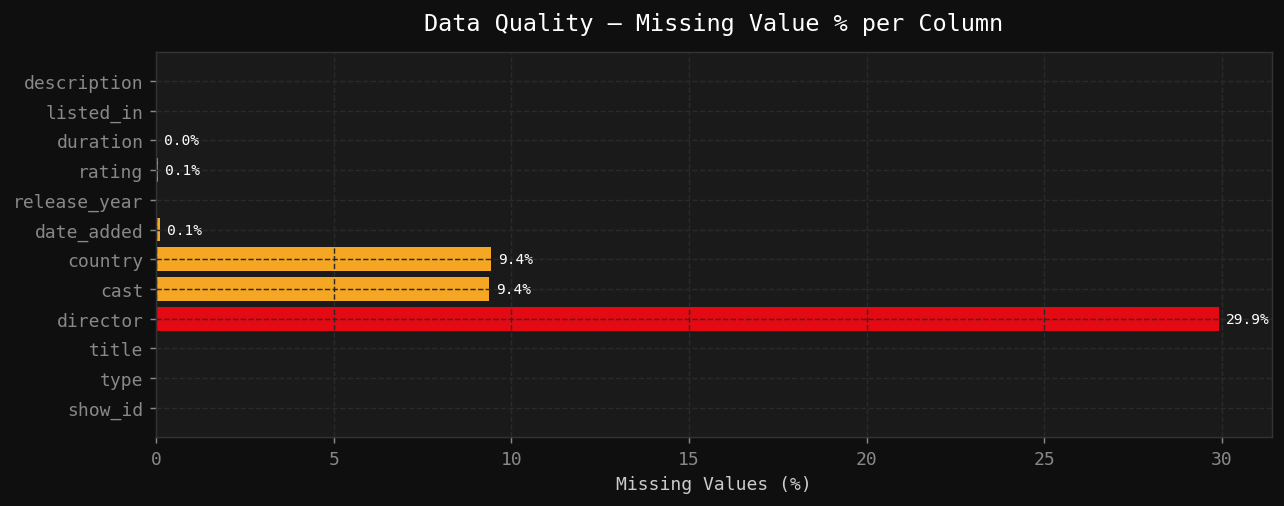


 After cleaning — Shape: 8,807 rows × 14 columns


In [5]:
print("\n" + "=" * 60)
print("SECTION 2 — DATA QUALITY AUDIT")
print("=" * 60)
 
null_counts  = df.isnull().sum()
null_pct     = (null_counts / len(df) * 100).round(2)
quality_df   = pd.DataFrame({'Missing Count': null_counts, 'Missing %': null_pct})
print(quality_df[quality_df['Missing Count'] > 0])
 
fig, ax = plt.subplots(figsize=(10, 4))
colors = [NETFLIX_RED if p > 10 else ACCENT if p > 0 else COOL
          for p in null_pct]
bars = ax.barh(null_pct.index, null_pct.values, color=colors, edgecolor='none')
ax.set_xlabel('Missing Values (%)')
ax.set_title('Data Quality — Missing Value % per Column', color='white',
             fontsize=13, pad=12)
for bar, val in zip(bars, null_pct.values):
    if val > 0:
        ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=8, color='white')
plt.tight_layout()
plt.savefig('01_missing_values.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
 
# Clean Data
df['director'] = df['director'].fillna('Unknown')
df['country']  = df['country'].fillna('Unknown')
df['cast']     = df['cast'].fillna('Unknown')
df['rating']   = df['rating'].fillna(df['rating'].mode()[0])
df = df.drop_duplicates()
 
# Parse dates
df['date_added']  = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
 
print(f"\n After cleaning — Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

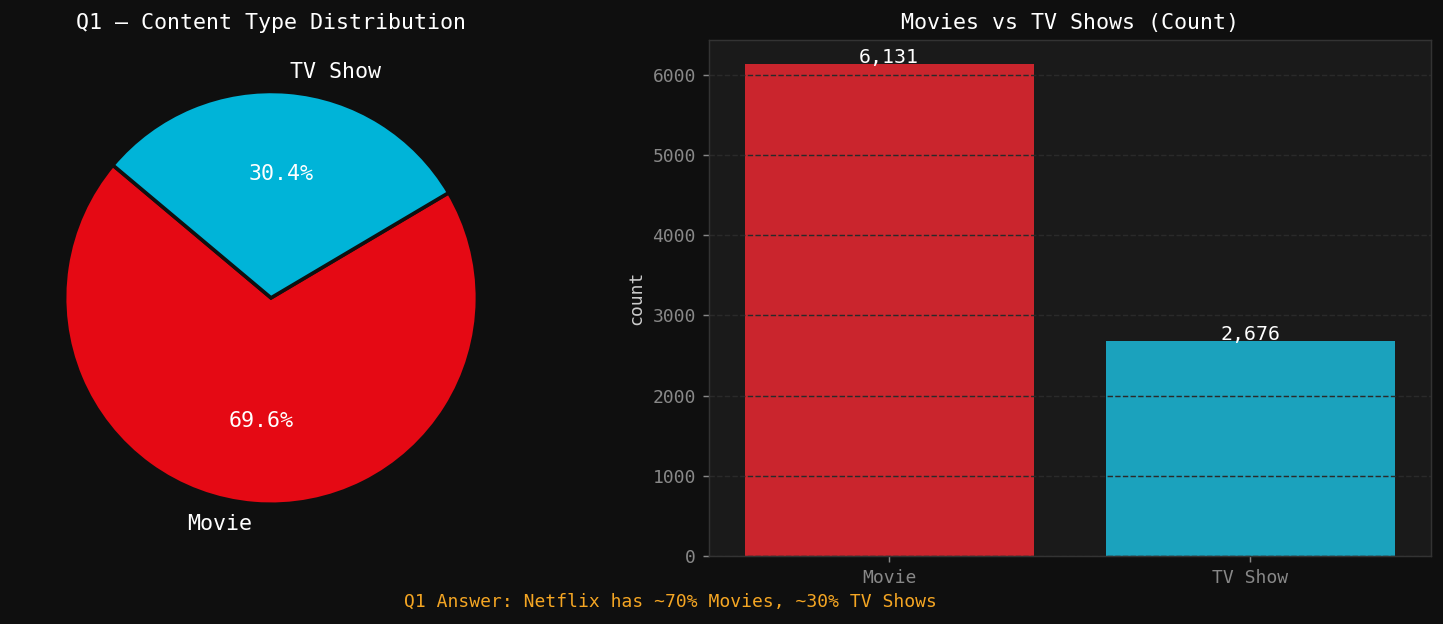

In [6]:
# Q1: Movies vs TV Shows
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
type_counts = df['type'].value_counts()
 
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=[NETFLIX_RED, COOL], startangle=140,
            wedgeprops={'edgecolor': '#0f0f0f', 'linewidth': 2},
            textprops={'color': 'white', 'fontsize': 12})
axes[0].set_title('Q1 — Content Type Distribution', color='white', fontsize=12)
 
sns.countplot(x='type', data=df, palette=[NETFLIX_RED, COOL], ax=axes[1],
              edgecolor='none')
axes[1].set_title('Movies vs TV Shows (Count)', color='white', fontsize=12)
axes[1].set_xlabel('')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 20),
                     ha='center', color='white', fontsize=11)
fig.suptitle('Q1 Answer: Netflix has ~70% Movies, ~30% TV Shows',
             color=ACCENT, fontsize=10, y=0.02)
plt.tight_layout()
plt.savefig('02_type_distribution.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

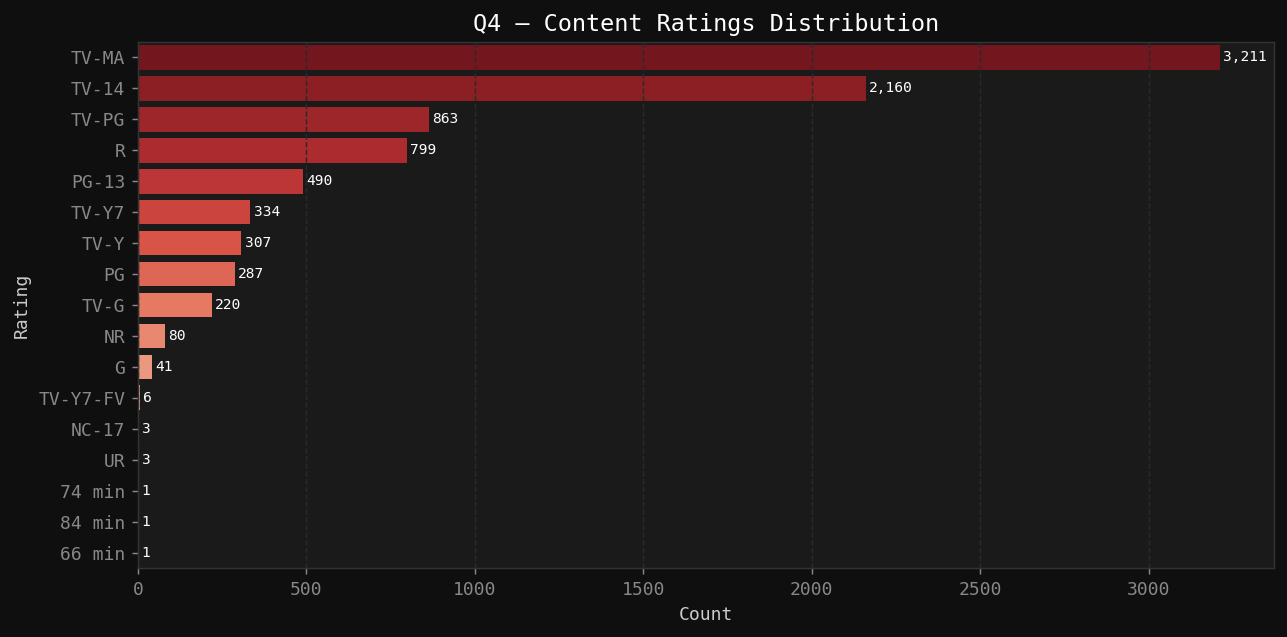

In [7]:
# Q4: Ratings Distribution
fig, ax = plt.subplots(figsize=(10, 5))
rating_order = df['rating'].value_counts().index
sns.countplot(y='rating', data=df, order=rating_order,
              palette='Reds_r', ax=ax, edgecolor='none')
ax.set_title('Q4 — Content Ratings Distribution', color='white', fontsize=13)
ax.set_xlabel('Count')
ax.set_ylabel('Rating')
for p in ax.patches:
    ax.text(p.get_width() + 10, p.get_y() + p.get_height() / 2,
            f'{int(p.get_width()):,}', va='center', fontsize=8, color='white')
plt.tight_layout()
plt.savefig('03_ratings.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

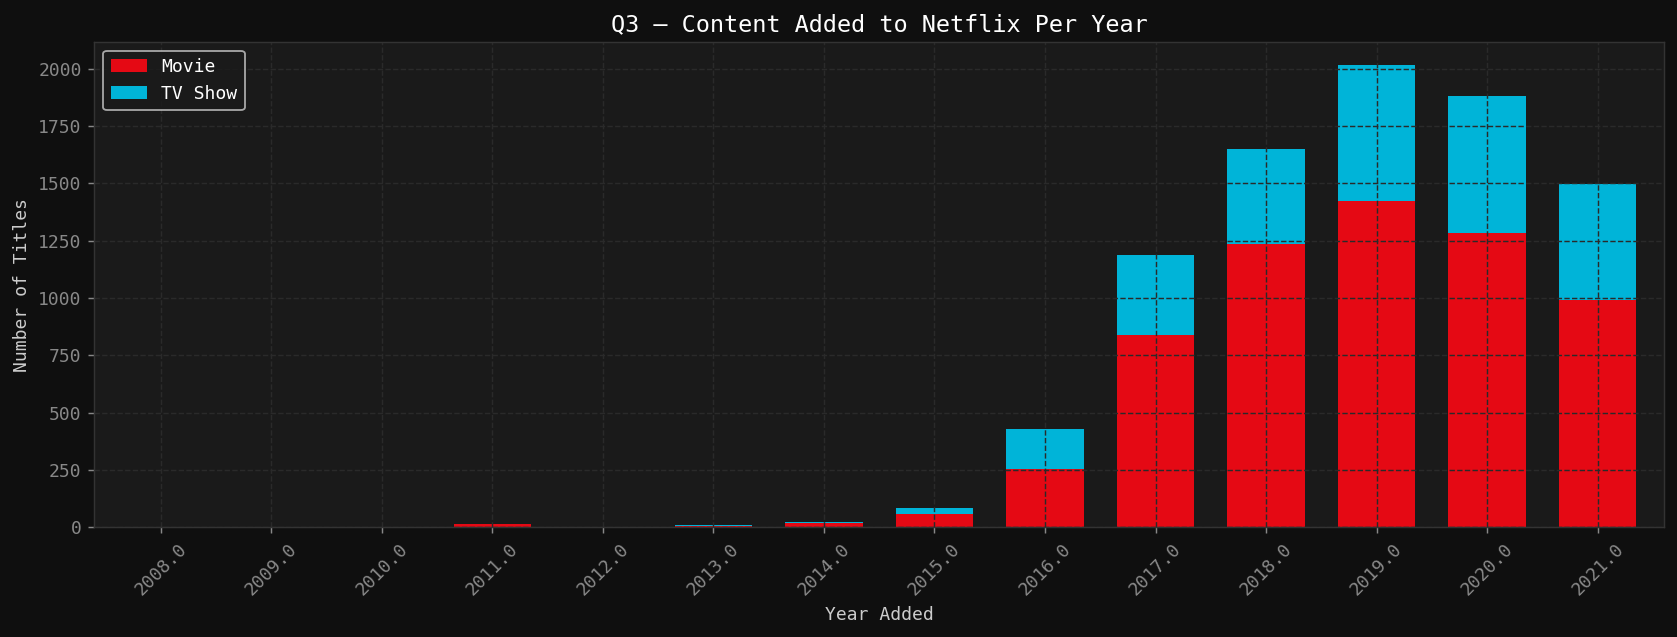

In [8]:
# Q3: Content added per year 
yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly = yearly[yearly.index.notna()]
 
fig, ax = plt.subplots(figsize=(13, 5))
yearly.plot(kind='bar', stacked=True, ax=ax,
            color=[NETFLIX_RED, COOL], edgecolor='none', width=0.7)
ax.set_title('Q3 — Content Added to Netflix Per Year', color='white', fontsize=13)
ax.set_xlabel('Year Added')
ax.set_ylabel('Number of Titles')
ax.legend(['Movie', 'TV Show'], facecolor='#1a1a1a', labelcolor='white')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('04_yearly_trend.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
 

TypeError: list indices must be integers or slices, not numpy.float64

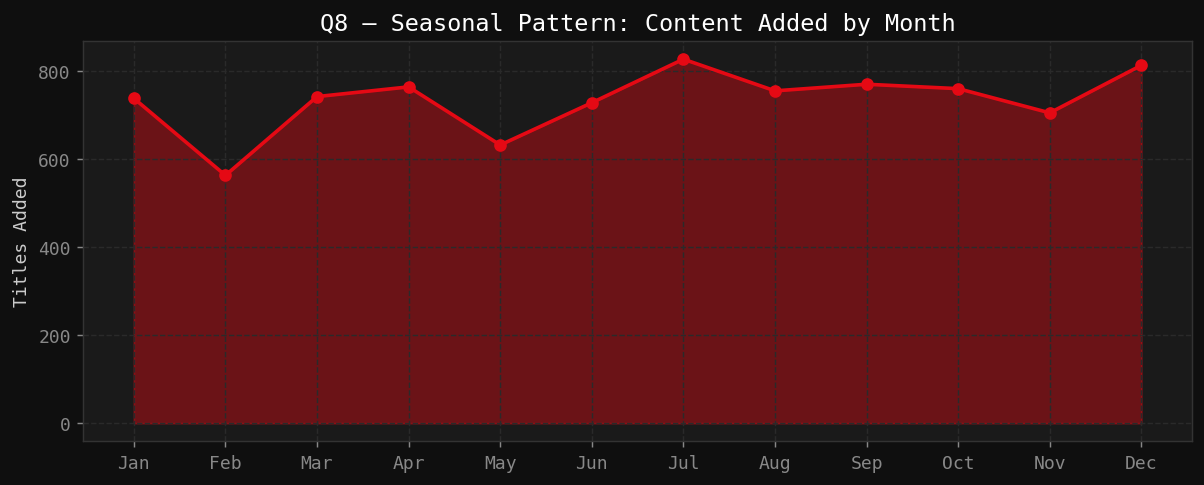

In [9]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df['month_added'].value_counts().sort_index()
 
fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(monthly.index, monthly.values, color=NETFLIX_RED, alpha=0.4)
ax.plot(monthly.index, monthly.values, color=NETFLIX_RED, linewidth=2, marker='o')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Q8 — Seasonal Pattern: Content Added by Month',
             color='white', fontsize=13)
ax.set_ylabel('Titles Added')
peak_month = monthly.idxmax()
ax.annotate(f'Peak: {month_names[peak_month-1]}',
            xy=(peak_month, monthly[peak_month]),
            xytext=(peak_month + 1, monthly[peak_month] + 50),
            arrowprops=dict(arrowstyle='->', color=ACCENT),
            color=ACCENT, fontsize=10)
plt.tight_layout()
plt.savefig('05_monthly_pattern.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

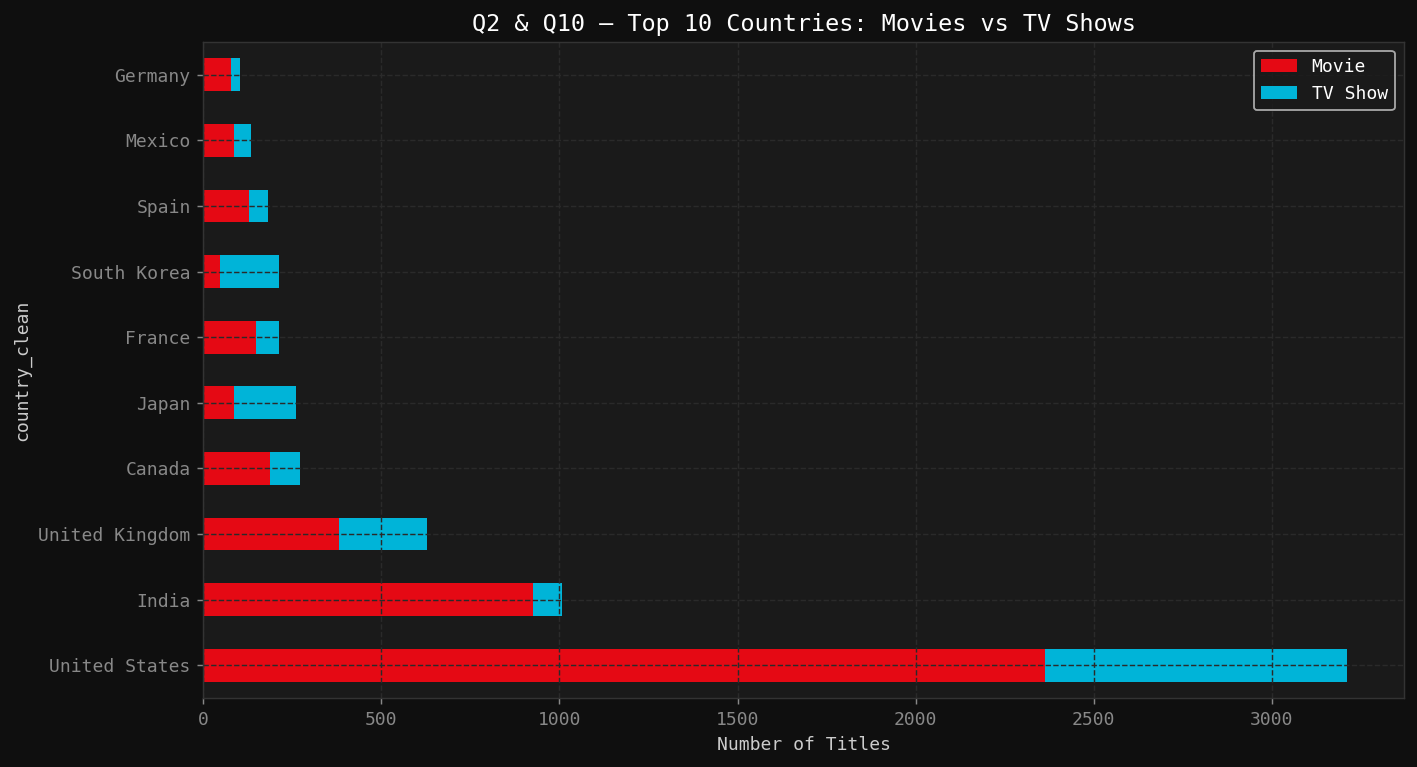

In [10]:
# Q2 & Q10: Top countries + content type split
# Expand multi-country entries
country_series = df['country'].str.split(',').explode().str.strip()
top10_countries = country_series[country_series != 'Unknown'] \
                     .value_counts().head(10).index.tolist()
 
country_type = (
    df[df['country'].str.contains('|'.join(top10_countries), na=False)]
    .assign(country_clean=lambda x: x['country'].str.split(',').str[0].str.strip())
    .groupby(['country_clean', 'type'])
    .size().unstack(fill_value=0)
)
country_type = country_type.loc[
    country_type.sum(axis=1).sort_values(ascending=False).head(10).index
]
 
fig, ax = plt.subplots(figsize=(11, 6))
country_type.plot(kind='barh', stacked=True, ax=ax,
                  color=[NETFLIX_RED, COOL], edgecolor='none')
ax.set_title('Q2 & Q10 — Top 10 Countries: Movies vs TV Shows',
             color='white', fontsize=13)
ax.set_xlabel('Number of Titles')
ax.legend(['Movie', 'TV Show'], facecolor='#1a1a1a', labelcolor='white')
plt.tight_layout()
plt.savefig('06_country_type.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

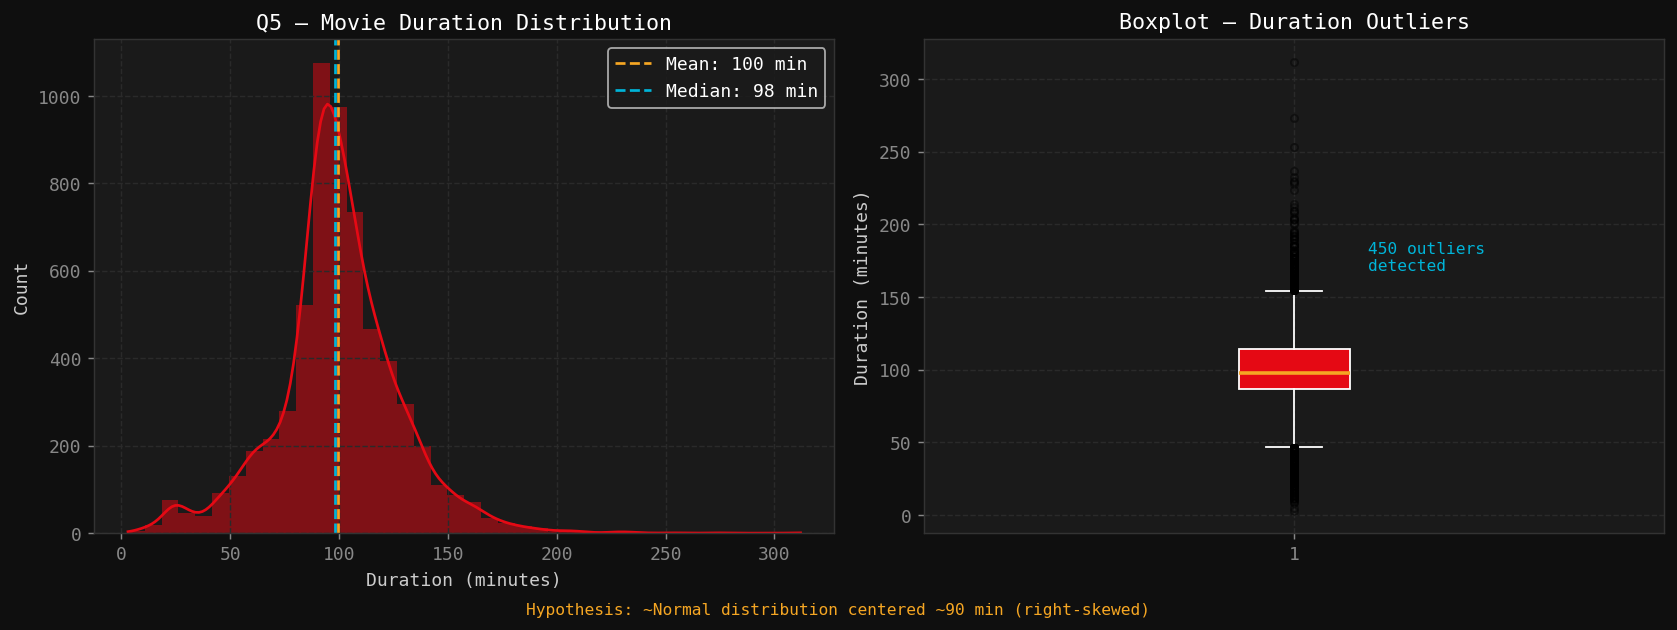


── Movie Duration Stats ──
count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_int, dtype: float64
 Outliers (IQR method): 450
                            title  duration_int
4253   Black Mirror: Bandersnatch           312
717   Headspace: Unwind Your Mind           273
2491       The School of Mischief           253
2487               No Longer kids           237
2484           Lock Your Girls In           233


In [11]:
movies = df[df['type'] == 'Movie'].copy()
movies = movies.dropna(subset=['duration'])
movies['duration_int'] = pd.to_numeric(
    movies['duration'].str.replace(' min', '', regex=False).str.strip(),
    errors='coerce'
)
movies = movies.dropna(subset=['duration_int'])
movies['duration_int'] = movies['duration_int'].astype(int)
 
# ── Hypothesis: Movie durations follow a normal distribution ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
sns.histplot(movies['duration_int'], bins=40, kde=True, ax=axes[0],
             color=NETFLIX_RED, edgecolor='none')
axes[0].axvline(movies['duration_int'].mean(), color=ACCENT,
                linestyle='--', label=f"Mean: {movies['duration_int'].mean():.0f} min")
axes[0].axvline(movies['duration_int'].median(), color=COOL,
                linestyle='--', label=f"Median: {movies['duration_int'].median():.0f} min")
axes[0].set_title('Q5 — Movie Duration Distribution', color='white', fontsize=12)
axes[0].set_xlabel('Duration (minutes)')
axes[0].legend(facecolor='#1a1a1a', labelcolor='white')
 
# Box plot with outlier annotation
bp = axes[1].boxplot(movies['duration_int'], vert=True, patch_artist=True,
                     boxprops=dict(facecolor=NETFLIX_RED, color='white'),
                     medianprops=dict(color=ACCENT, linewidth=2),
                     whiskerprops=dict(color='white'),
                     capprops=dict(color='white'),
                     flierprops=dict(marker='o', color=COOL, alpha=0.4,
                                     markersize=4))
axes[1].set_title('Boxplot — Duration Outliers', color='white', fontsize=12)
axes[1].set_ylabel('Duration (minutes)')
 
Q1 = movies['duration_int'].quantile(0.25)
Q3 = movies['duration_int'].quantile(0.75)
IQR = Q3 - Q1
outliers = movies[(movies['duration_int'] < Q1 - 1.5 * IQR) |
                  (movies['duration_int'] > Q3 + 1.5 * IQR)]
axes[1].annotate(f'{len(outliers)} outliers\ndetected',
                 xy=(1.1, Q3 + 2 * IQR),
                 color=COOL, fontsize=9)
 
fig.suptitle('Hypothesis: ~Normal distribution centered ~90 min (right-skewed)',
             color=ACCENT, fontsize=9, y=0.01)
plt.tight_layout()
plt.savefig('07_duration_analysis.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
 
print(f"\n── Movie Duration Stats ──")
print(movies['duration_int'].describe())
print(f" Outliers (IQR method): {len(outliers)}")
print(outliers[['title', 'duration_int']].sort_values('duration_int',
                                                        ascending=False).head(5))

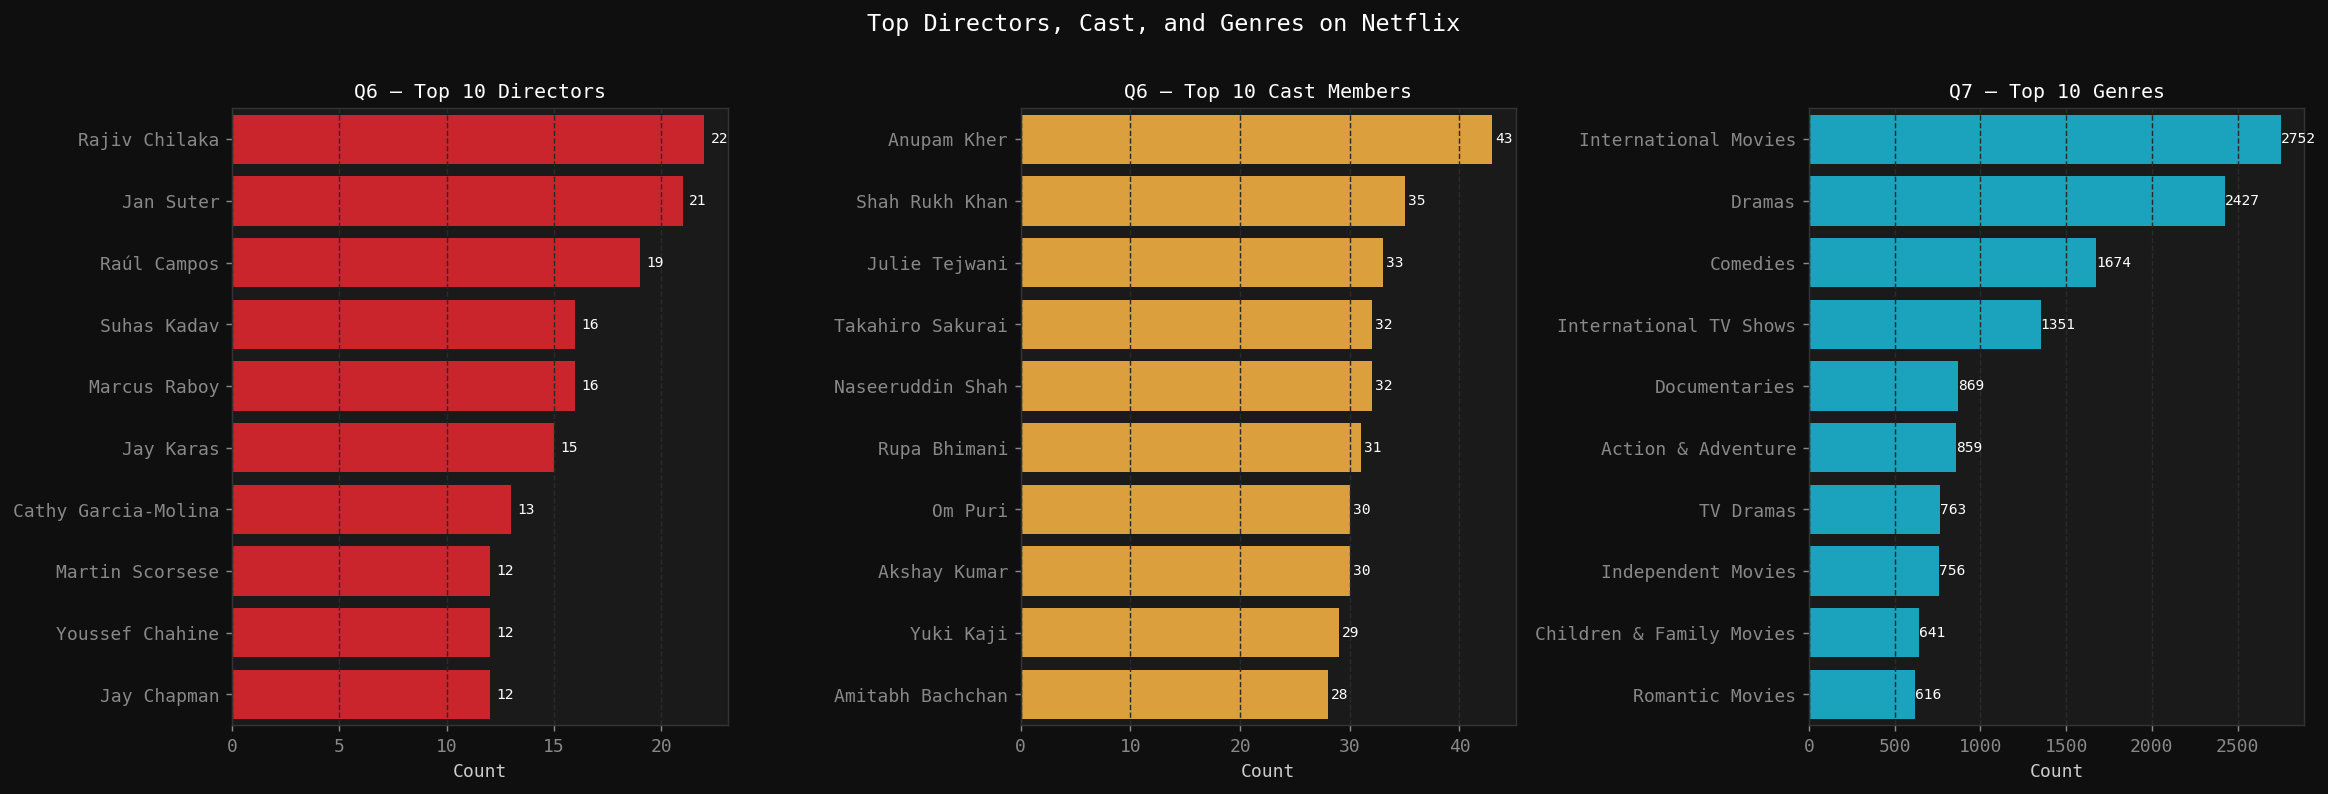

In [12]:
def top_n_from_column(series, n=10, exclude='Unknown'):
    all_vals = series.dropna().str.split(',').explode().str.strip()
    return all_vals[all_vals != exclude].value_counts().head(n)
 
top_directors = top_n_from_column(df['director'])
top_cast      = top_n_from_column(df['cast'])
top_genres    = top_n_from_column(df['listed_in'])
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
datasets = [
    (top_directors, 'Q6 — Top 10 Directors', NETFLIX_RED),
    (top_cast,      'Q6 — Top 10 Cast Members', ACCENT),
    (top_genres,    'Q7 — Top 10 Genres', COOL),
]
for ax, (data, title, color) in zip(axes, datasets):
    sns.barplot(x=data.values, y=data.index, ax=ax,
                color=color, edgecolor='none')
    ax.set_title(title, color='white', fontsize=11)
    ax.set_xlabel('Count')
    ax.set_ylabel('')
    for p in ax.patches:
        ax.text(p.get_width() + 0.3, p.get_y() + p.get_height() / 2,
                str(int(p.get_width())), va='center', fontsize=8, color='white')
plt.suptitle('Top Directors, Cast, and Genres on Netflix',
             color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('08_top_directors_cast_genres.png', bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()

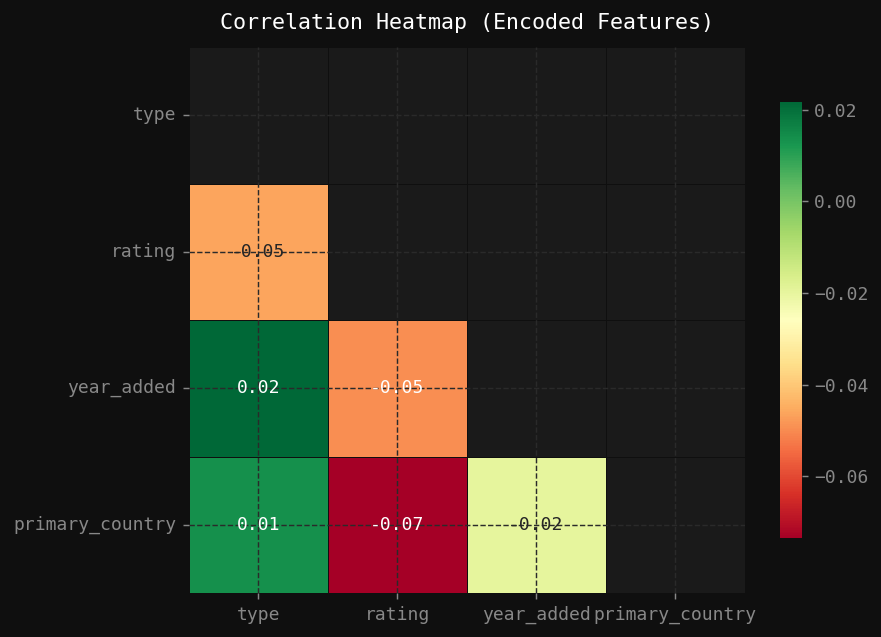

In [13]:
# Encode top-level country and rating for correlation
df['primary_country'] = df['country'].str.split(',').str[0].str.strip()
heat_df = df[['type', 'rating', 'year_added', 'primary_country']].copy()
for col in ['type', 'rating', 'primary_country']:
    heat_df[col] = pd.factorize(heat_df[col])[0]
heat_df = heat_df.dropna()
 
fig, ax = plt.subplots(figsize=(7, 5))
corr = heat_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', mask=mask,
            ax=ax, linewidths=0.5, linecolor='#0f0f0f',
            annot_kws={'size': 10},
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Encoded Features)',
             color='white', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('09_correlation_heatmap.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()